# 4. ĐÁNH GIÁ MÔ HÌNH & KHOẢNG DỰ ĐOÁN

Phần này tiếp tục sử dụng đúng mô hình hồi quy tuyến tính đa biến ở `03_mlr.ipynb`:

- Biến phụ thuộc (Y): `Monthly_Return`
- Biến độc lập (X1): `Interest_Rate`
- Biến độc lập (X2): `Inflation_Rate`
- Phương pháp ước lượng: OLS

Mục tiêu của phần này là phân tích phần dư (Residual), tính Residual Standard Error (RSE), xây dựng Confidence Interval (CI) và Prediction Interval (PI), sau đó phân biệt ý nghĩa của hai loại khoảng.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

candidate_paths = [
    Path('../data/msft_macro_2021_2026.csv'),
    Path('data/msft_macro_2021_2026.csv'),
    Path('/content/msft_macro_2021_2026.csv'),
    Path('msft_macro_2021_2026.csv')
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Không tìm thấy file msft_macro_2021_2026.csv')

print('Data path:', DATA_PATH)

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['Monthly_Return'] = df['MSFT_Price'].pct_change() * 100
df = df.dropna(subset=['Monthly_Return']).reset_index(drop=True)

X = df[['Interest_Rate', 'Inflation_Rate']]
Y = df['Monthly_Return']
X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()

print('Số quan sát:', int(results.nobs))
print('Df Residuals:', int(results.df_resid))
print('R-squared:', round(results.rsquared, 4))

Data path: ../data/msft_macro_2021_2026.csv
Số quan sát: 67
Df Residuals: 64
R-squared: 0.0113


## 4.1. Phân tích Residual

Residual (phần dư) là chênh lệch giữa giá trị Monthly Return thực tế và giá trị mà mô hình dự đoán:

\[
e_i = y_i - \hat{y}_i
\]

Residual được sử dụng để quan sát phần sai số mà mô hình chưa giải thích được. Nếu mô hình tuyến tính phù hợp, các residual thường phân bố quanh mức 0 và không hình thành một quy luật rõ ràng theo giá trị dự báo.

In [2]:
fitted_values = results.fittedvalues
residuals = results.resid

residual_summary = pd.DataFrame({
    'Chỉ tiêu': ['Mean Residual', 'Std. Dev. Residual', 'Min Residual', 'Max Residual'],
    'Giá trị': [
        residuals.mean(),
        residuals.std(ddof=1),
        residuals.min(),
        residuals.max()
    ]
})
print('=== Tóm tắt Residual ===')
display(residual_summary.round(4))

=== Tóm tắt Residual ===


,Chỉ tiêu,Giá trị
0,Mean Residual,-0.0000
1,Std. Dev. Residual,7.5978
2,Min Residual,-19.0352
3,Max Residual,22.6395


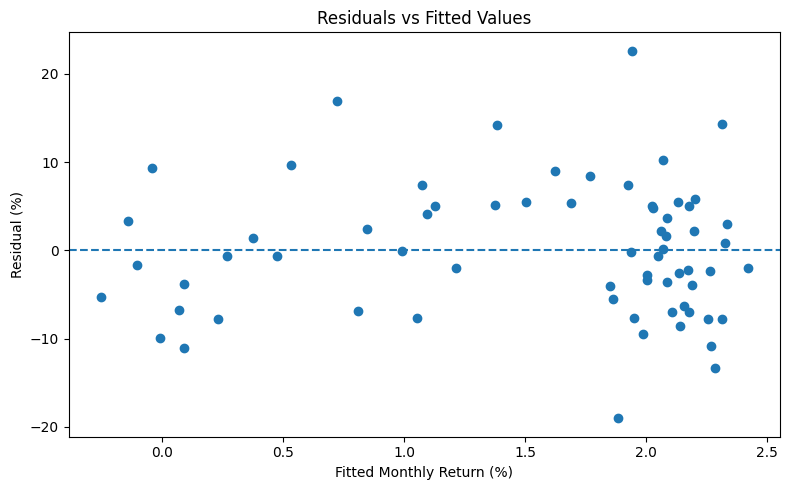

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted Monthly Return (%)')
plt.ylabel('Residual (%)')
plt.title('Residuals vs Fitted Values')
plt.tight_layout()
plt.show()

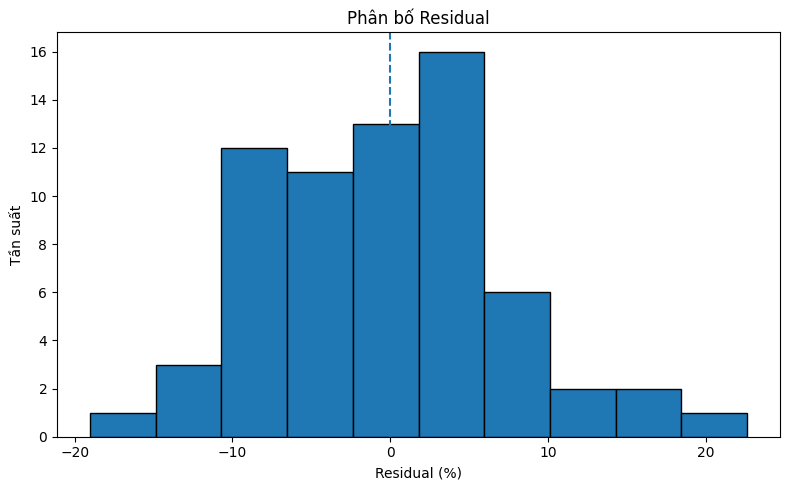

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=10, edgecolor='black')
plt.axvline(0, linestyle='--')
plt.xlabel('Residual (%)')
plt.ylabel('Tần suất')
plt.title('Phân bố Residual')
plt.tight_layout()
plt.show()

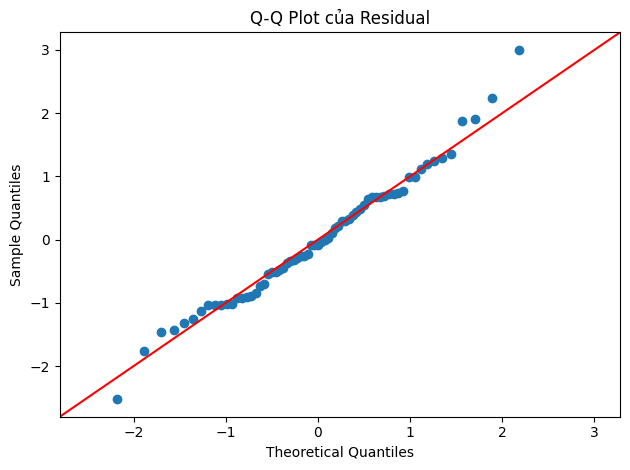

Durbin-Watson: 2.0599


In [5]:
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot của Residual')
plt.tight_layout()
plt.show()

durbin_watson = sm.stats.stattools.durbin_watson(residuals)
print('Durbin-Watson:', round(durbin_watson, 4))

Kết quả cho thấy Mean Residual xấp xỉ **0**, phù hợp với đặc điểm của mô hình OLS có hệ số chặn. Residual nhỏ nhất khoảng **-19,0352%** và lớn nhất khoảng **22,6395%**, cho thấy vẫn tồn tại một số quan sát có sai số dự báo tương đối lớn.

Trên biểu đồ Residuals vs Fitted Values, các phần dư phân bố ở cả hai phía của đường 0 và không thể hiện một dạng cong rõ ràng. Tuy nhiên, độ phân tán của residual vẫn tương đối lớn tại một số vùng giá trị dự báo.

Q-Q Plot cho thấy phần lớn các điểm nằm tương đối gần đường tham chiếu, mặc dù một số quan sát ở hai đầu phân phối có độ lệch nhất định. Do đó, phân phối phần dư nhìn chung không cho thấy sai lệch quá nghiêm trọng, nhưng vẫn tồn tại một số quan sát cực trị.

Chỉ số Durbin-Watson khoảng **2,0599**, gần mức 2, cho thấy không có dấu hiệu rõ rệt của tự tương quan bậc nhất trong phần dư.

## 4.2. Tính và đánh giá RSE

Residual Standard Error (RSE) phản ánh độ lớn điển hình của sai số dự báo quanh đường hồi quy. Với mô hình có \(n\) quan sát và \(k\) biến độc lập, RSE được tính theo công thức:

\[
RSE = \sqrt{\frac{\sum e_i^2}{n-k-1}}
\]

Trong mô hình hiện tại, số quan sát là 67 và có 2 biến độc lập, do đó bậc tự do phần dư là 64.

In [6]:
SSE = np.sum(residuals ** 2)
RSE = np.sqrt(SSE / results.df_resid)

print(f'SSE = {SSE:.4f}')
print(f'RSE = {RSE:.4f} điểm phần trăm')

SSE = 3809.9492
RSE = 7.7156 điểm phần trăm


Kết quả tính toán cho thấy SSE của mô hình bằng **3.809,9492** và RSE bằng **7,7156 điểm phần trăm**. Điều này cho thấy sai số giữa Monthly Return thực tế và giá trị dự báo của mô hình có độ lớn điển hình khoảng 7,72 điểm phần trăm.

So với độ lệch chuẩn của Monthly Return trong mẫu là khoảng **7,6411%**, RSE có độ lớn tương đối tương đương. Kết quả này phù hợp với R² thấp của mô hình, cho thấy Interest Rate và Inflation Rate chỉ giải thích được một phần rất nhỏ biến động của lợi suất hàng tháng MSFT.

## 4.3. Confidence Interval (CI)

Confidence Interval (CI) được sử dụng để ước lượng khoảng chứa **giá trị trung bình kỳ vọng** của Monthly Return tại một bộ giá trị Interest Rate và Inflation Rate cụ thể.

Để minh họa phương pháp mà không lấn sang phần kịch bản ở Phần 5, phần này sử dụng một điểm đại diện trong mẫu: Interest Rate và Inflation Rate được đặt bằng **giá trị trung bình của dữ liệu nghiên cứu**.

Mức tin cậy được sử dụng là 95%.

In [7]:
interest_mean = df['Interest_Rate'].mean()
inflation_mean = df['Inflation_Rate'].mean()

x0 = pd.DataFrame({
    'const': [1.0],
    'Interest_Rate': [interest_mean],
    'Inflation_Rate': [inflation_mean]
})[X.columns]

prediction = results.get_prediction(x0)
pred_summary = prediction.summary_frame(alpha=0.05)

ci_pi_table = pd.DataFrame({
    'Interest_Rate (%)': [interest_mean],
    'Inflation_Rate (%)': [inflation_mean],
    'Monthly Return dự báo (%)': [pred_summary.loc[0, 'mean']],
    'CI 95% - Cận dưới (%)': [pred_summary.loc[0, 'mean_ci_lower']],
    'CI 95% - Cận trên (%)': [pred_summary.loc[0, 'mean_ci_upper']],
    'PI 95% - Cận dưới (%)': [pred_summary.loc[0, 'obs_ci_lower']],
    'PI 95% - Cận trên (%)': [pred_summary.loc[0, 'obs_ci_upper']]
})

display(ci_pi_table.round(4))

print(f'Interest Rate trung bình = {interest_mean:.4f}%')
print(f'Inflation Rate trung bình = {inflation_mean:.4f}%')
print(f'Monthly Return dự báo = {pred_summary.loc[0, "mean"]:.4f}%')
print(f'CI 95% = [{pred_summary.loc[0, "mean_ci_lower"]:.4f}%; {pred_summary.loc[0, "mean_ci_upper"]:.4f}%]')

,Interest_Rate (%),Inflation_Rate (%),Monthly Return dự báo (%),CI 95% - Cận dưới (%),CI 95% - Cận trên (%),PI 95% - Cận dưới (%),PI 95% - Cận trên (%)
0,3.324,4.3948,1.5273,-0.3558,3.4103,-14.001,17.0555


Interest Rate trung bình = 3.3240%
Inflation Rate trung bình = 4.3948%
Monthly Return dự báo = 1.5273%
CI 95% = [-0.3558%; 3.4103%]


Giá trị trung bình của Interest Rate trong mẫu là **3,3240%**, trong khi Inflation Rate trung bình là **4,3948%**. Tại bộ giá trị này, mô hình dự báo Monthly Return trung bình của MSFT bằng khoảng **1,5273%**.

Confidence Interval 95% cho giá trị trung bình kỳ vọng của Monthly Return là:

**[-0,3558%; 3,4103%]**

Khoảng này bao gồm giá trị 0, cho thấy tại mức lãi suất và lạm phát đại diện cho trung bình mẫu, lợi suất trung bình kỳ vọng vẫn có mức độ bất định đáng kể. Cần lưu ý rằng CI ở đây được sử dụng để ước lượng **giá trị trung bình kỳ vọng**, không phải lợi suất của một tháng riêng lẻ.

## 4.4. Prediction Interval (PI)

Prediction Interval (PI) được sử dụng để ước lượng khoảng có khả năng chứa **một giá trị Monthly Return mới** khi Interest Rate và Inflation Rate có cùng mức đã xác định ở trên.

Khác với CI, PI không chỉ phản ánh độ bất định của giá trị trung bình ước lượng mà còn bao gồm biến động riêng của một quan sát mới. Vì vậy, PI thường rộng hơn CI.

In [8]:
ci_lower = pred_summary.loc[0, 'mean_ci_lower']
ci_upper = pred_summary.loc[0, 'mean_ci_upper']
pi_lower = pred_summary.loc[0, 'obs_ci_lower']
pi_upper = pred_summary.loc[0, 'obs_ci_upper']

ci_width = ci_upper - ci_lower
pi_width = pi_upper - pi_lower

print(f'Giá trị dự báo trung tâm: {pred_summary.loc[0, "mean"]:.4f}%')
print(f'Confidence Interval 95%: [{ci_lower:.4f}%; {ci_upper:.4f}%]')
print(f'Prediction Interval 95%: [{pi_lower:.4f}%; {pi_upper:.4f}%]')
print(f'Độ rộng CI: {ci_width:.4f} điểm phần trăm')
print(f'Độ rộng PI: {pi_width:.4f} điểm phần trăm')

Giá trị dự báo trung tâm: 1.5273%
Confidence Interval 95%: [-0.3558%; 3.4103%]
Prediction Interval 95%: [-14.0010%; 17.0555%]
Độ rộng CI: 3.7662 điểm phần trăm
Độ rộng PI: 31.0566 điểm phần trăm


Với cùng bộ giá trị Interest Rate và Inflation Rate, Prediction Interval 95% cho một quan sát Monthly Return mới là:

**[-14,0010%; 17,0555%]**

Khoảng dự đoán có độ rộng khoảng **31,0566 điểm phần trăm**, lớn hơn đáng kể so với độ rộng **3,7662 điểm phần trăm** của Confidence Interval.

Kết quả này cho thấy mặc dù mô hình có thể ước lượng giá trị trung bình với một khoảng tương đối hẹp hơn, lợi suất của một tháng riêng lẻ vẫn có thể biến động trong phạm vi rất rộng.

## 4.5. Phân biệt Confidence Interval và Prediction Interval

| Tiêu chí | Confidence Interval (CI) | Prediction Interval (PI) |
|---|---|---|
| Đối tượng ước lượng | Giá trị trung bình kỳ vọng của Monthly Return | Một giá trị Monthly Return mới |
| Nguồn bất định | Sai số khi ước lượng giá trị trung bình | Sai số ước lượng trung bình + biến động của quan sát mới |
| Độ rộng | Hẹp hơn | Rộng hơn |
| Cách diễn giải trong bài | Khoảng cho mức lợi suất trung bình kỳ vọng dưới một điều kiện vĩ mô cụ thể | Khoảng cho một tháng mới có cùng điều kiện vĩ mô |

Như vậy, Confidence Interval và Prediction Interval phục vụ hai mục đích khác nhau. CI phản ánh mức độ bất định khi ước lượng lợi suất trung bình kỳ vọng tại một bộ điều kiện kinh tế vĩ mô cụ thể, trong khi PI phản ánh phạm vi mà một quan sát lợi suất mới có thể xuất hiện. Do PI bao gồm cả sai số trong việc ước lượng giá trị trung bình và biến động riêng của quan sát mới, khoảng này rộng hơn CI đáng kể.

## Kết luận Phần 4

Phân tích phần dư cho thấy residual có giá trị trung bình xấp xỉ 0 và phân bố ở cả hai phía của đường hồi quy. Tuy nhiên, một số quan sát vẫn có sai số tương đối lớn, với residual dao động từ khoảng -19,04% đến 22,64%. Chỉ số Durbin-Watson bằng 2,0599 không cho thấy dấu hiệu rõ rệt của tự tương quan bậc nhất trong phần dư.

RSE của mô hình đạt **7,7156 điểm phần trăm**, gần tương đương với độ lệch chuẩn của Monthly Return trong mẫu. Kết quả này phù hợp với R² thấp được ghi nhận ở Phần 3, cho thấy khả năng giải thích biến động lợi suất của mô hình còn hạn chế.

Tại mức Interest Rate và Inflation Rate trung bình của mẫu, Monthly Return dự báo là khoảng **1,5273%**, với Confidence Interval 95% từ **-0,3558% đến 3,4103%**. Trong khi đó, Prediction Interval 95% rộng hơn đáng kể, từ **-14,0010% đến 17,0555%**. Điều này cho thấy độ bất định khi dự báo lợi suất của một tháng riêng lẻ vẫn tương đối lớn, ngay cả khi mô hình có thể đưa ra một giá trị dự báo trung tâm.